In [2]:
%pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('historical_avengers_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

sectors = df['sector_id'].unique()
print("Sectors:", sectors)
print("\nData shape:", df.shape)
df.head()

Sectors: <StringArray>
['New Asgard', 'Wakanda', 'Sokovia', 'Sanctum Sanctorum', 'Avengers Compound']
Length: 5, dtype: str

Data shape: (10000, 6)


,timestamp,sector_id,resource_type,stock_level,usage_rate_hourly,snap_event_detected
0,2026-01-01,New Asgard,Vibranium (kg),2500.0,6.43,False
1,2026-01-01,Wakanda,Arc Reactor Cores,800.0,6.13,False
2,2026-01-01,Sokovia,Pym Particles,800.0,7.39,False
3,2026-01-01,Sanctum Sanctorum,Clean Water (L),2500.0,5.44,False
4,2026-01-01,Avengers Compound,Medical Kits,800.0,3.48,False


# Resource Analysis Overview

In [4]:
print("Data Summary by Sector:\n")
summary = df.groupby('sector_id').agg({
    'stock_level': ['mean', 'min', 'max'],
    'usage_rate_hourly': ['mean', 'min', 'max'],
    'snap_event_detected': 'sum'
}).round(2)
summary.columns = ['Avg Stock', 'Min Stock', 'Max Stock', 'Avg Usage', 'Min Usage', 'Max Usage', 'Snap Events']
print(summary)

Data Summary by Sector:

                   Avg Stock  Min Stock  Max Stock  Avg Usage  Min Usage  \
sector_id                                                                  
Avengers Compound     181.60        0.0      800.0       5.03       2.00   
New Asgard           1508.73        0.0     2500.0       4.99       2.00   
Sanctum Sanctorum    1512.70        0.0     2500.0       4.95       2.00   
Sokovia               185.38        0.0      800.0       5.01       2.01   
Wakanda               184.90        0.0      800.0       4.97       2.00   

                   Max Usage  Snap Events  
sector_id                                  
Avengers Compound       8.00            8  
New Asgard              8.00            7  
Sanctum Sanctorum       7.99            8  
Sokovia                 7.99            8  
Wakanda                 8.00            8  


## Stock Level Over Time by Sector

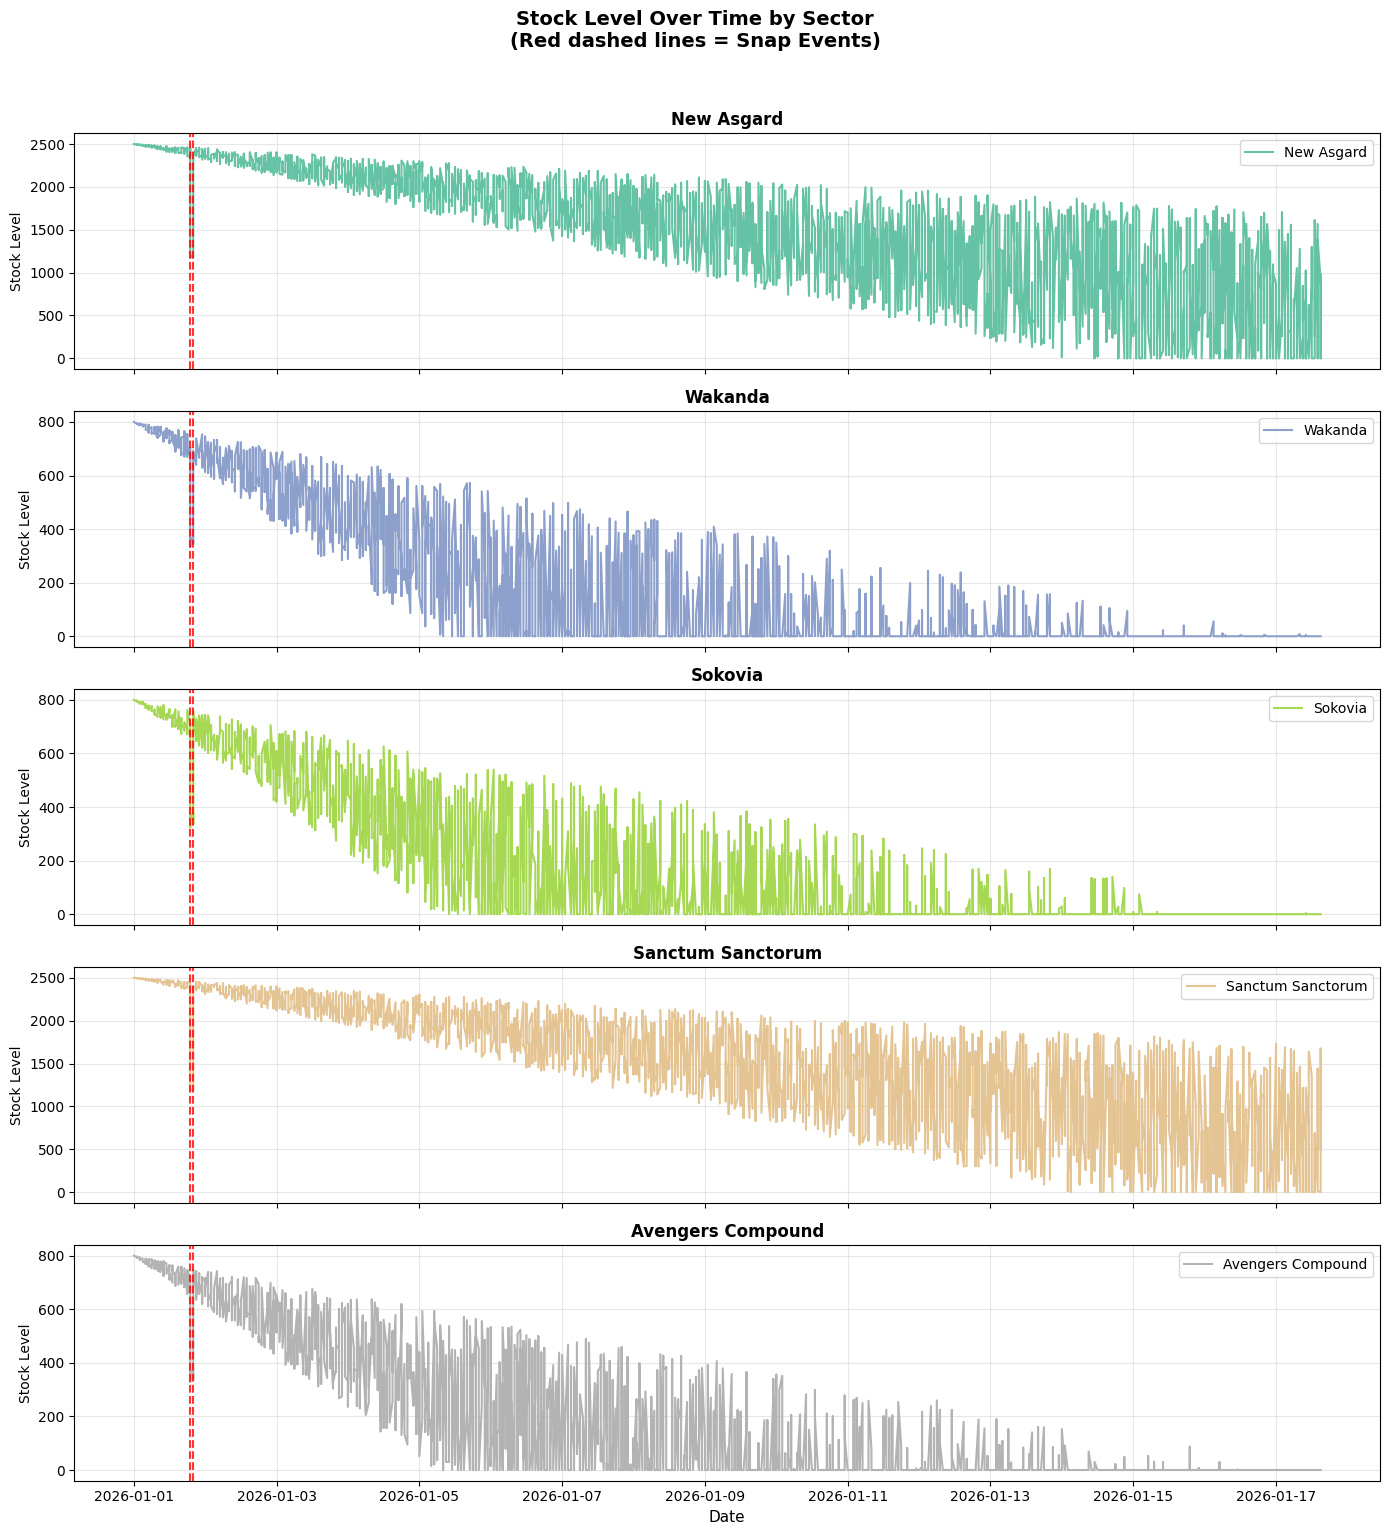

In [5]:
fig, axes = plt.subplots(len(sectors), 1, figsize=(14, 3*len(sectors)), sharex=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))

for idx, sector in enumerate(sectors):
    sector_data = df[df['sector_id'] == sector].sort_values('timestamp')
    ax = axes[idx]
    
    ax.plot(sector_data['timestamp'], sector_data['stock_level'], 
            color=colors[idx], linewidth=1.5, label=sector)
    
    snap_events = sector_data[sector_data['snap_event_detected'] == True]
    for snap_time in snap_events['timestamp'].unique():
        ax.axvline(x=snap_time, color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    
    ax.set_ylabel('Stock Level', fontsize=10)
    ax.set_title(f'{sector}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Stock Level Over Time by Sector\n(Red dashed lines = Snap Events)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Usage Rate Over Time by Sector

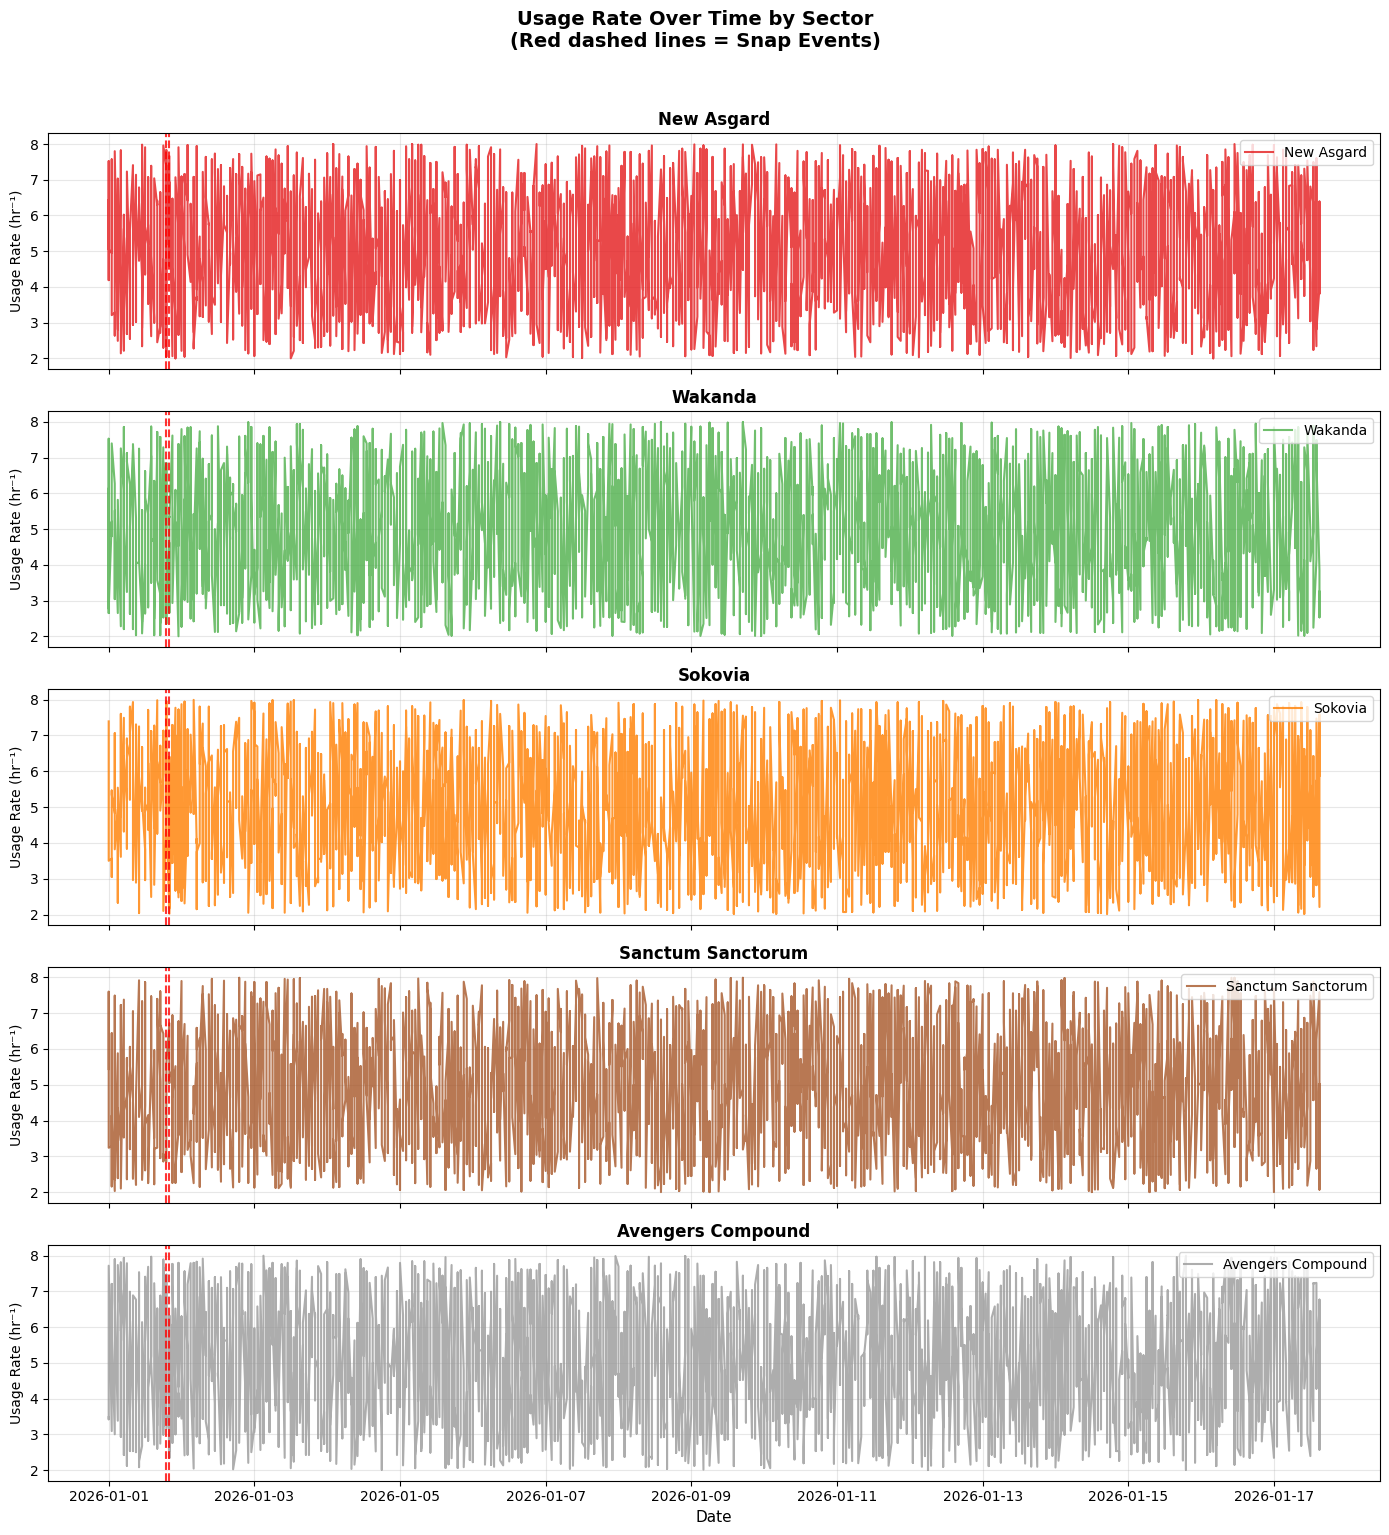

In [6]:
fig, axes = plt.subplots(len(sectors), 1, figsize=(14, 3*len(sectors)), sharex=True)
colors = plt.cm.Set1(np.linspace(0, 1, len(sectors)))

for idx, sector in enumerate(sectors):
    sector_data = df[df['sector_id'] == sector].sort_values('timestamp')
    ax = axes[idx]
    
    ax.plot(sector_data['timestamp'], sector_data['usage_rate_hourly'], 
            color=colors[idx], linewidth=1.5, label=sector, alpha=0.8)
    
    snap_events = sector_data[sector_data['snap_event_detected'] == True]
    for snap_time in snap_events['timestamp'].unique():
        ax.axvline(x=snap_time, color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    
    ax.set_ylabel('Usage Rate (hr⁻¹)', fontsize=10)
    ax.set_title(f'{sector}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Usage Rate Over Time by Sector\n(Red dashed lines = Snap Events)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Stock Level vs Usage Rate Over Time

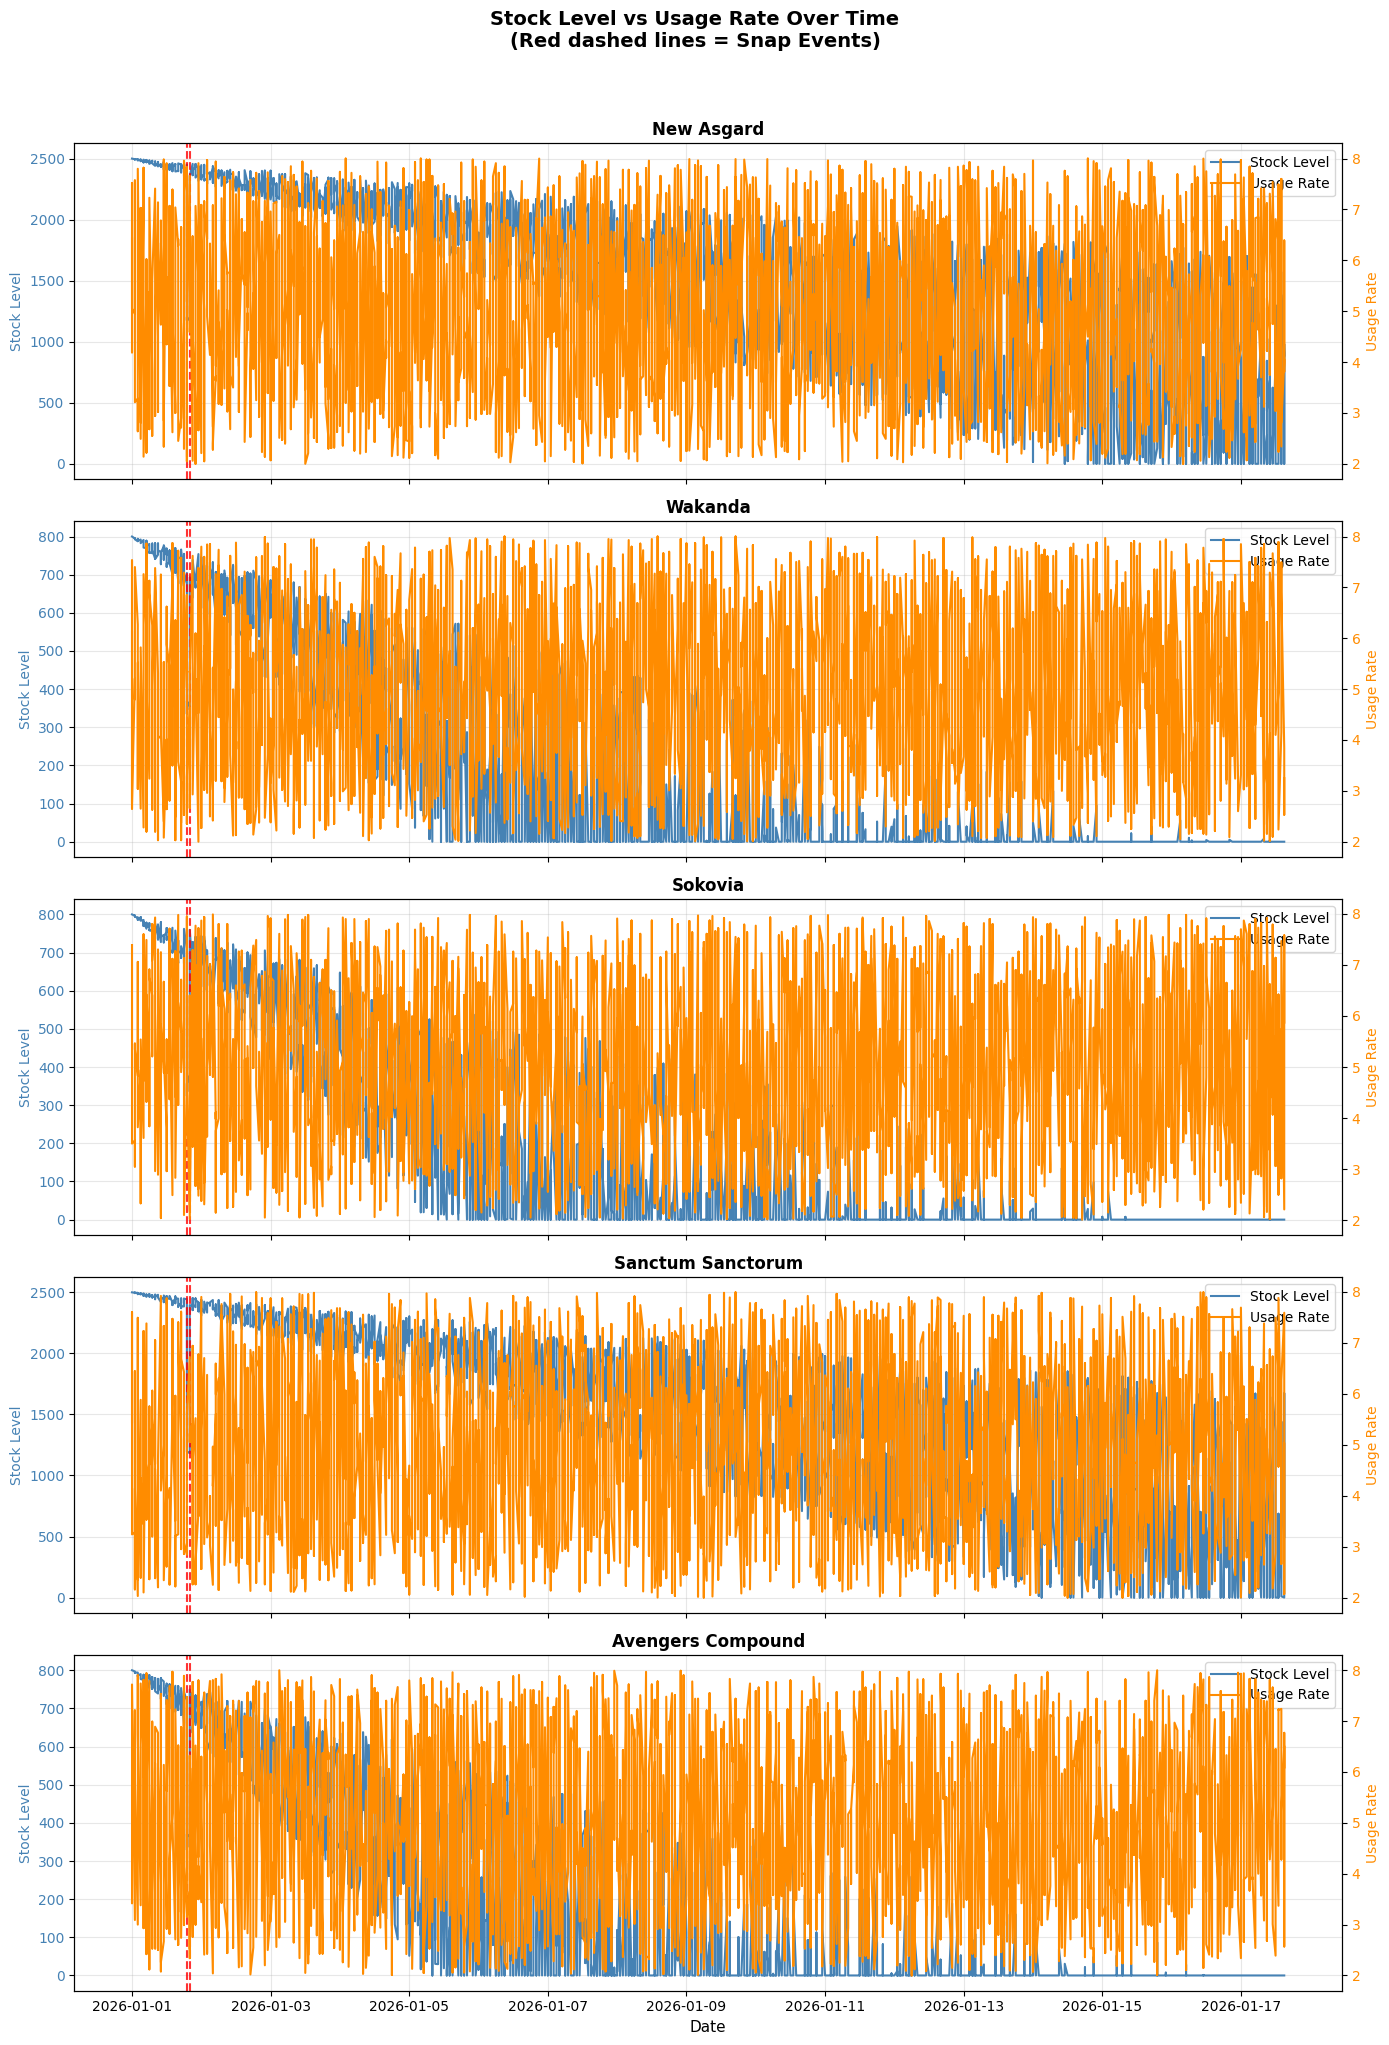

In [7]:
fig, axes = plt.subplots(len(sectors), 1, figsize=(14, 4*len(sectors)), sharex=True)

for idx, sector in enumerate(sectors):
    sector_data = df[df['sector_id'] == sector].sort_values('timestamp')
    ax = axes[idx]
    ax2 = ax.twinx()
    
    line1 = ax.plot(sector_data['timestamp'], sector_data['stock_level'], 
                    color='steelblue', linewidth=1.5, label='Stock Level')
    line2 = ax2.plot(sector_data['timestamp'], sector_data['usage_rate_hourly'], 
                     color='darkorange', linewidth=1.5, label='Usage Rate')
    
    snap_events = sector_data[sector_data['snap_event_detected'] == True]
    for snap_time in snap_events['timestamp'].unique():
        ax.axvline(x=snap_time, color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    
    ax.set_ylabel('Stock Level', color='steelblue', fontsize=10)
    ax2.set_ylabel('Usage Rate', color='darkorange', fontsize=10)
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax.set_title(f'{sector}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper right')

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Stock Level vs Usage Rate Over Time\n(Red dashed lines = Snap Events)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Correlation Analysis

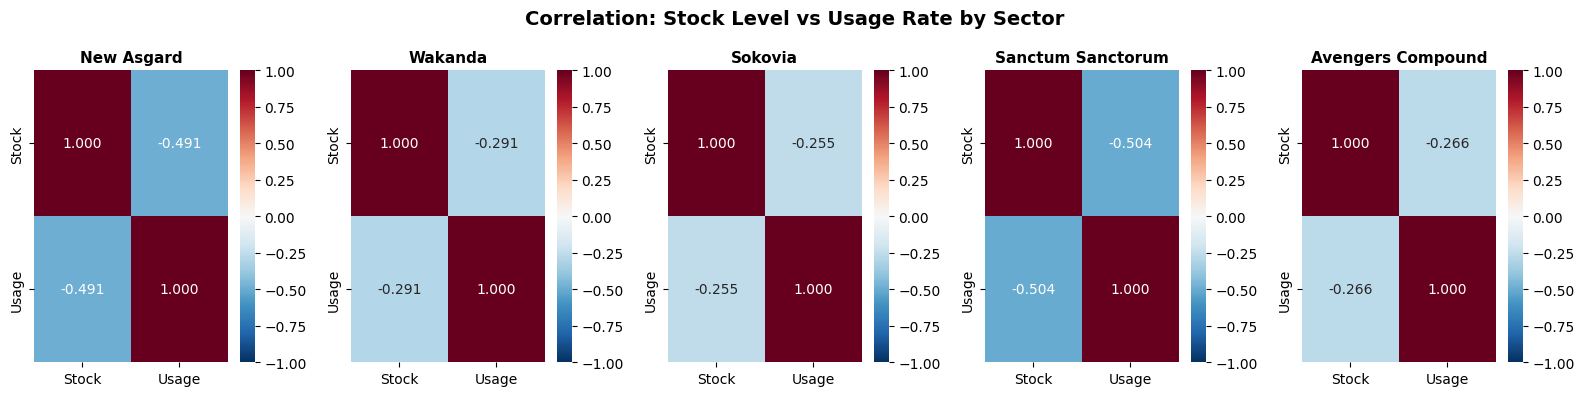

In [8]:
fig, axes = plt.subplots(1, len(sectors), figsize=(16, 4))

for idx, sector in enumerate(sectors):
    sector_data = df[df['sector_id'] == sector]
    corr = sector_data[['stock_level', 'usage_rate_hourly']].corr()
    
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, 
                fmt='.3f', ax=axes[idx], vmin=-1, vmax=1,
                xticklabels=['Stock', 'Usage'],
                yticklabels=['Stock', 'Usage'])
    axes[idx].set_title(f'{sector}', fontsize=11, fontweight='bold')

plt.suptitle('Correlation: Stock Level vs Usage Rate by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution Analysis

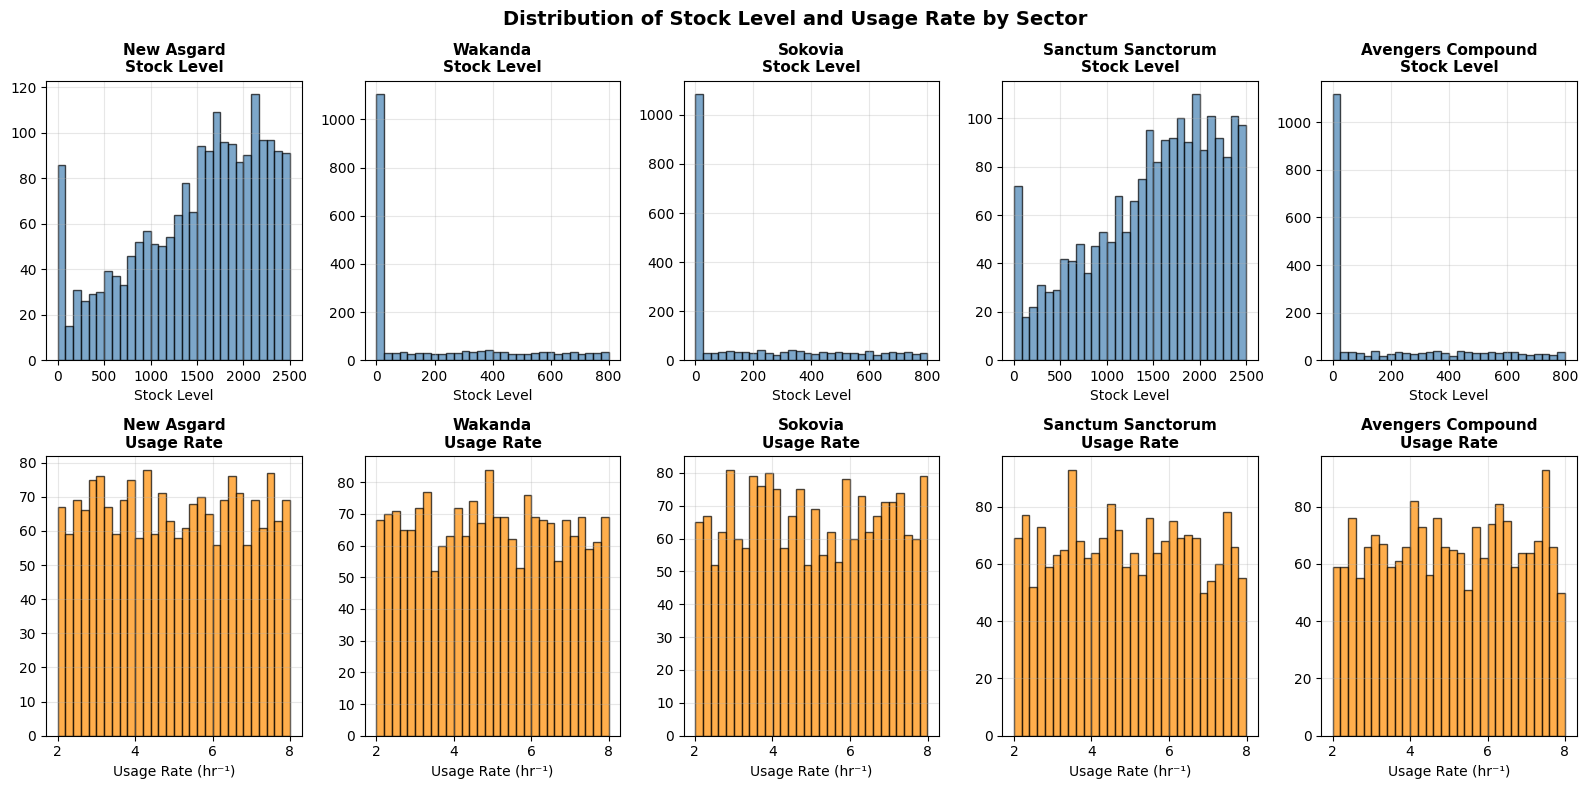

In [9]:
fig, axes = plt.subplots(2, len(sectors), figsize=(16, 8))

for idx, sector in enumerate(sectors):
    sector_data = df[df['sector_id'] == sector]
    
    axes[0, idx].hist(sector_data['stock_level'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{sector}\nStock Level', fontsize=11, fontweight='bold')
    axes[0, idx].set_xlabel('Stock Level')
    axes[0, idx].grid(True, alpha=0.3)
    
    axes[1, idx].hist(sector_data['usage_rate_hourly'], bins=30, color='darkorange', alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(f'{sector}\nUsage Rate', fontsize=11, fontweight='bold')
    axes[1, idx].set_xlabel('Usage Rate (hr⁻¹)')
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Distribution of Stock Level and Usage Rate by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Hourly Analysis

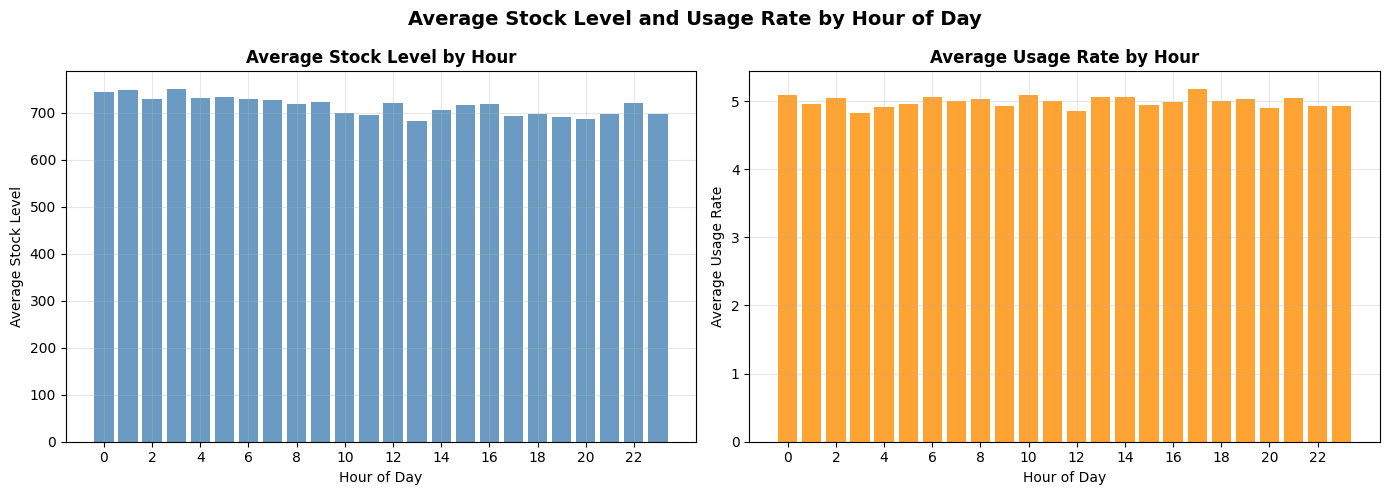

In [10]:
df['hour'] = df['timestamp'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_stock = df.groupby('hour')['stock_level'].mean()
hourly_usage = df.groupby('hour')['usage_rate_hourly'].mean()

axes[0].bar(hourly_stock.index, hourly_stock.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Stock Level')
axes[0].set_title('Average Stock Level by Hour', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

axes[1].bar(hourly_usage.index, hourly_usage.values, color='darkorange', alpha=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Usage Rate')
axes[1].set_title('Average Usage Rate by Hour', fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Average Stock Level and Usage Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Snap Event Analysis

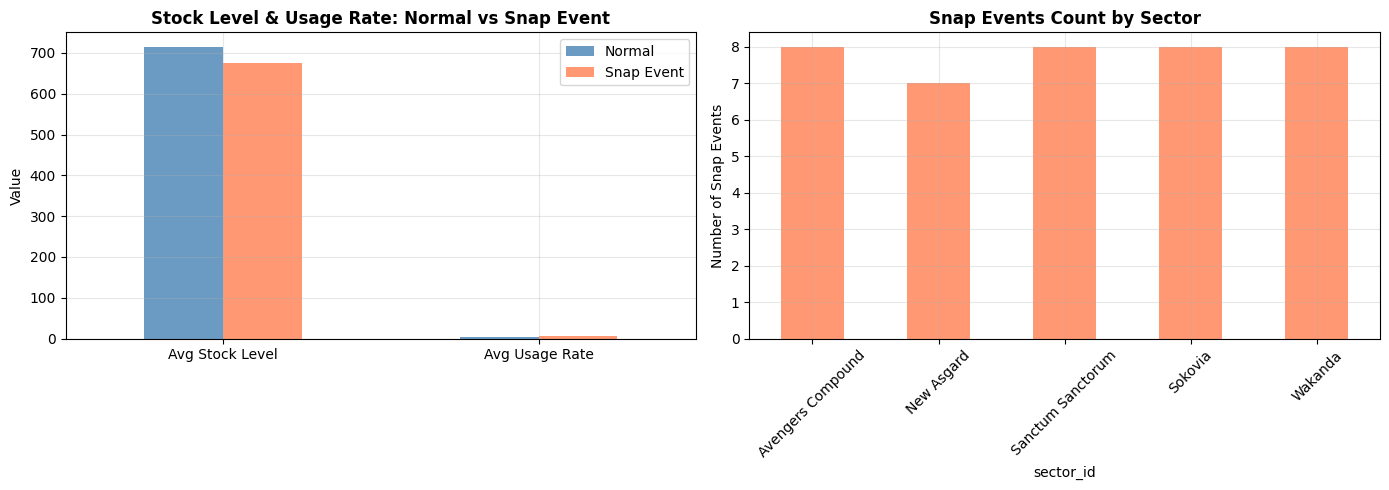

In [11]:
snap_events = df[df['snap_event_detected'] == True]
normal_events = df[df['snap_event_detected'] == False]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_data = pd.DataFrame({
    'Normal': [normal_events['stock_level'].mean(), normal_events['usage_rate_hourly'].mean()],
    'Snap Event': [snap_events['stock_level'].mean(), snap_events['usage_rate_hourly'].mean()]
}, index=['Avg Stock Level', 'Avg Usage Rate'])

comparison_data.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], alpha=0.8)
axes[0].set_title('Stock Level & Usage Rate: Normal vs Snap Event', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

snap_counts = df.groupby('sector_id')['snap_event_detected'].sum()
snap_counts.plot(kind='bar', ax=axes[1], color='coral', alpha=0.8)
axes[1].set_title('Snap Events Count by Sector', fontweight='bold')
axes[1].set_ylabel('Number of Snap Events')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Box Plot Comparison by Sector

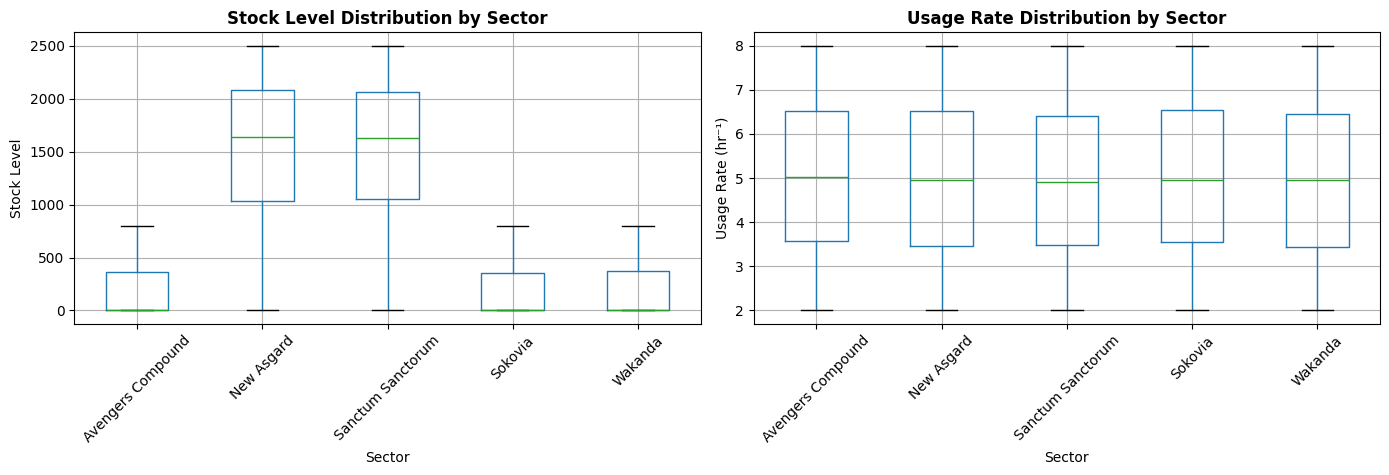

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='stock_level', by='sector_id', ax=axes[0])
axes[0].set_title('Stock Level Distribution by Sector', fontweight='bold')
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Stock Level')
axes[0].tick_params(axis='x', rotation=45)
plt.suptitle('')

df.boxplot(column='usage_rate_hourly', by='sector_id', ax=axes[1])
axes[1].set_title('Usage Rate Distribution by Sector', fontweight='bold')
axes[1].set_xlabel('Sector')
axes[1].set_ylabel('Usage Rate (hr⁻¹)')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()